# Atlas mapping workflow

Rather than a stand-alone classifier, this workflow **maps a new query dataset
onto a reference PDAC atlas** in the atlas's own SCANVI latent space, so query
cells can be visualised and annotated side-by-side with the reference.

`scpdac` exposes two entry points:

- `scpdac.tl.extend_atlas` — performs **scArches surgery** on the packaged SCANVI
  model, fine-tuning it on your query (which may introduce entirely new batches),
  then returns an **expanded atlas** containing both reference and query cells in a
  shared embedding — while **retaining all of your query metadata**.
  *Requires the reference atlas (large download, see Section 1).*
- `scpdac.tl.embed_and_predict` — the lightweight, no-surgery path: it embeds the
  query with the frozen reference model and transfers labels, without modifying
  the atlas. *Does **not** require the atlas — the model ships with `scpdac`.*

In this tutorial we run both on the
[Chen et al. 2025](https://www.cell.com/cancer-cell/fulltext/S1535-6108(25)00393-9)
cohort and compare the resulting UMAPs.

> **👉 Which sections do you need?**
>
> | Goal | Sections to run |
> |---|---|
> | **Just get an embedding + transferred labels for your data** | Setup → **skip Section 1 and 2** → Section 3 (load *your* data) → **jump to Section 6** |
> | Place your data inside the full reference atlas | Everything |
>
> **You do not need to download the atlas** if you only want an embedding and
> label transfer for your own cells.

In [1]:
import tarfile
import urllib.request
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import pandas as pd
import anndata as ad
import scpdac
import scanpy as sc
from sklearn_ann.kneighbors.annoy import AnnoyTransformer

## Configure paths

All files are written below `DATA_DIR`. Change it to any location with enough
free disk space (the atlas alone needs **~40 GB** while being extracted).
Everything else in the notebook is derived from these variables.

In [ ]:
SPECIES = "human"  # the tutorial uses the human atlas / model ("mouse" is also available)

DATA_DIR = Path("data")  # <-- change 
ATLAS_DIR = DATA_DIR / "atlas"
QUERY_DIR = DATA_DIR / "chen_2025"  # replace with your own data

ATLAS_URL = f"https://zenodo.org/records/22970037/files/{SPECIES}_pdac_atlas_harmonised.zarr.tar.gz"
ATLAS_TAR = ATLAS_DIR / f"{SPECIES}_pdac_atlas_harmonised.zarr.tar.gz"
ATLAS_ZARR = ATLAS_DIR / f"{SPECIES}_pdac_atlas_Harmonised.zarr"

In [ ]:
def download(url: str, dest: Path) -> Path:
    """Download ``url`` to ``dest`` unless it already exists (safe to re-run)."""
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists():
        print(f"Already present, skipping: {dest}")
        return dest
    tmp = dest.with_name(dest.name + ".part")
    print(f"Downloading {url}\n  -> {dest}")
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(dest)
    return dest

## 1. Download the reference atlas (only for `extend_atlas`)

> **🚨 STOP — THIS IS A VERY LARGE DOWNLOAD 🚨**
>
> The integrated atlases are hosted on Zenodo:
> [zenodo.org/records/22970037](https://zenodo.org/records/22970037)
>
> | File | Compressed size |
> |---|---|
> | `human_pdac_atlas_harmonised.zarr.tar.gz` | **~19 GB** |
> | `mouse_pdac_atlas_harmonised.zarr.tar.gz` | **~12 GB** |
>
> - You need roughly **2× that in free disk space** (archive + extracted `zarr`).
> - Loading the full atlas into memory needs **a lot of RAM** (tens of GB) —
>   run this on a workstation or cluster node, not a laptop.
> - The download can take **hours** on a slow connection.
>
> **❗ You do NOT need the atlas if you only want an embedding and label transfer
> for your own data.** In that case skip Sections 1 and 2, load your data in
> Section 3, and jump straight to **Section 6 (`embed_and_predict`)**.

For a large, resumable download you may prefer the command line:

```bash
wget -c https://zenodo.org/records/22970037/files/human_pdac_atlas_harmonised.zarr.tar.gz
```

The cell below does the same from Python and skips files that already exist.

In [ ]:
download(ATLAS_URL, ATLAS_TAR)

if not ATLAS_ZARR.exists():
    with tarfile.open(ATLAS_TAR) as tar:
        tar.extractall(ATLAS_DIR)
ATLAS_ZARR

## 2. Download the example query (tutorial only)

We use the [Chen et al. 2025](https://www.cell.com/cancer-cell/fulltext/S1535-6108(25)00393-9)
PDAC cohort (GEO accession `GSE278688`) — 14 samples and roughly 200,000 cells —
as an example query.

> **⚠️ Example data only — replace it with your own**
>
> The Chen et al. 2025 cohort is used **purely as a worked example**. In a real
> analysis you should **replace it with your own dataset** and skip the download
> below entirely.
>
> **Download size:** ~1.1 GB (mostly `matrix.mtx.gz`). Reading the full matrix
> (~200,000 cells) into memory needs several GB of RAM.

In [ ]:
GEO_URL = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE278688&format=file&file=GSE278688_sc_{}"

for fname in ["features.tsv.gz", "barcodes.tsv.gz", "matrix.mtx.gz", "metadata.csv.gz"]:
    download(GEO_URL.format(fname), QUERY_DIR / fname)

## 3. Load the query

The query needs **raw counts** and a `Sample_ID` batch column.

**Using your own data?** Replace the next few cells with a single load of your
`AnnData`, e.g.

```python
query = sc.read_h5ad("path/to/your_data.h5ad")
```

and make sure it has **raw counts** in `layers["counts"]` and a per-sample batch
column in `obs["Sample_ID"]`.

In [2]:
query = sc.read_10x_mtx(QUERY_DIR)

The published metadata uses `patients` as the sample identifier, so we rename it
to the `Sample_ID` convention used throughout `scpdac`.

In [3]:
cell_metadata = pd.read_csv(QUERY_DIR / "metadata.csv.gz", index_col=0)

In [4]:
cell_metadata = cell_metadata.rename(
    columns={
        "patients": "Sample_ID",
    }
)

In [5]:
query.obs = cell_metadata
len(query.obs.Sample_ID.unique())

14

Keep an untouched copy of the raw counts in `layers["counts"]` for the model to
bin and embed.

In [6]:
query.layers["counts"] = query.X.copy()

For a fast demo we restrict the query to two patients. Drop this cell to map
your full dataset.

In [7]:
query = query[query.obs.Sample_ID.isin(["PA01", "PA02"])].copy()

## 4. Load the reference atlas (only for `extend_atlas`)

> ⚠️ Skip this section (and Section 5) if you only need `embed_and_predict`.

Any atlas stored as `zarr`/`h5ad` with raw counts in `layers["counts"]` works.
Loading the full atlas needs a lot of memory; for a quick demo we subsample it to
100,000 cells (set `ATLAS_N_CELLS = None` to keep every cell).

In [8]:
ATLAS_N_CELLS = 100_000  # None -> use the full atlas

atlas = ad.read_zarr(ATLAS_ZARR)
if ATLAS_N_CELLS is not None and atlas.n_obs > ATLAS_N_CELLS:
    sc.pp.subsample(atlas, n_obs=ATLAS_N_CELLS, random_state=0)

In [9]:
query, atlas

(AnnData object with n_obs × n_vars = 9631 × 30543
     obs: 'tissue', 'Sample_ID', 'all_celltype'
     var: 'gene_ids', 'feature_types'
     layers: 'counts',
 AnnData object with n_obs × n_vars = 100000 × 39041
     obs: 'Sample_ID', 'Condition', 'Treatment', 'TreatmentType', 'TreatmentStatus', 'Tissue', 'Sex', 'Dataset', 'Technology', 'Level_1', 'Level_2', 'Level_3', 'Level_4', 'Age', 'Diabetes', 'Is_Core', 'EMT category', 'Dataset_ID', 'Cluster_Names'
     var: 'n_cells', 'ensembl_id', 'start', 'end', 'chromosome', 'gene_name_adata_sc', 'highly_variable_adata_sc', 'means_adata_sc', 'dispersions_adata_sc', 'dispersions_norm_adata_sc', 'highly_variable_nbatches_adata_sc', 'highly_variable_intersection_adata_sc', 'n_cells_by_counts_adata_sc', 'mean_counts_adata_sc', 'log1p_mean_counts_adata_sc', 'pct_dropout_by_counts_adata_sc', 'total_counts_adata_sc', 'log1p_total_counts_adata_sc', 'mito_adata_sc', 'n_cells_by_counts_adata_sn', 'mean_counts_adata_sn', 'log1p_mean_counts_adata_sn', '

## 5. Expand the atlas with scArches surgery

`scpdac.tl.extend_atlas` fine-tunes the packaged SCANVI model on the query
(`max_epochs` controls the surgery length), embeds both atlas and query into the
shared latent space, and concatenates them into a single expanded `AnnData`. The
result carries a `source` column (`atlas` / `query`), predicted labels in
`predicted_celltype`, and every original query `obs` column.

In [10]:
expanded = scpdac.tl.extend_atlas(query, atlas, species=SPECIES, max_epochs=10)

 captum (see https://github.com/pytorch/captum).


INFO     File .../scpdac/models/scanvi/human_scanvi/model.pt already       
         downloaded                                                                                                
INFO     Training for 10 epochs.                                                                                   


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more detail

Epoch 10/10: 100%|██████████| 10/10 [00:08<00:00,  1.30it/s, v_num=1, train_loss_step=1.78e+3, train_loss_epoch=1.86e+3]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [00:08<00:00,  1.24it/s, v_num=1, train_loss_step=1.78e+3, train_loss_epoch=1.86e+3]


In [11]:
expanded

AnnData object with n_obs × n_vars = 109631 × 29305
    obs: 'Sample_ID', 'Condition', 'Treatment', 'TreatmentType', 'TreatmentStatus', 'Tissue', 'Sex', 'Dataset', 'Technology', 'Level_1', 'Level_2', 'Level_3', 'Level_4', 'Age', 'Diabetes', 'Is_Core', 'EMT category', 'Dataset_ID', 'Cluster_Names', 'source', 'predicted_celltype'
    var: 'n_cells', 'ensembl_id', 'start', 'end', 'chromosome', 'gene_name_adata_sc', 'highly_variable_adata_sc', 'means_adata_sc', 'dispersions_adata_sc', 'dispersions_norm_adata_sc', 'highly_variable_nbatches_adata_sc', 'highly_variable_intersection_adata_sc', 'n_cells_by_counts_adata_sc', 'mean_counts_adata_sc', 'log1p_mean_counts_adata_sc', 'pct_dropout_by_counts_adata_sc', 'total_counts_adata_sc', 'log1p_total_counts_adata_sc', 'mito_adata_sc', 'n_cells_by_counts_adata_sn', 'mean_counts_adata_sn', 'log1p_mean_counts_adata_sn', 'pct_dropout_by_counts_adata_sn', 'total_counts_adata_sn', 'log1p_total_counts_adata_sn', 'Manual_Genes', 'mt', 'ribo', 'hb', 'gene_

### Visualise the expanded atlas

We build a joint UMAP directly from the shared `X_scANVI_emb` embedding — no PCA
needed, since the SCANVI latent space is already the integrated representation.

In [12]:
sc.pp.neighbors(expanded, use_rep="X_scANVI_emb", transformer=AnnoyTransformer(15))

In [13]:
sc.tl.umap(
    expanded,
)

Colouring by `predicted_celltype` shows the transferred annotations across the
combined embedding; highlighting `source == "query"` shows where the new cells
land relative to the reference. Well-integrated query cells intermix with matching
reference populations rather than forming isolated islands.

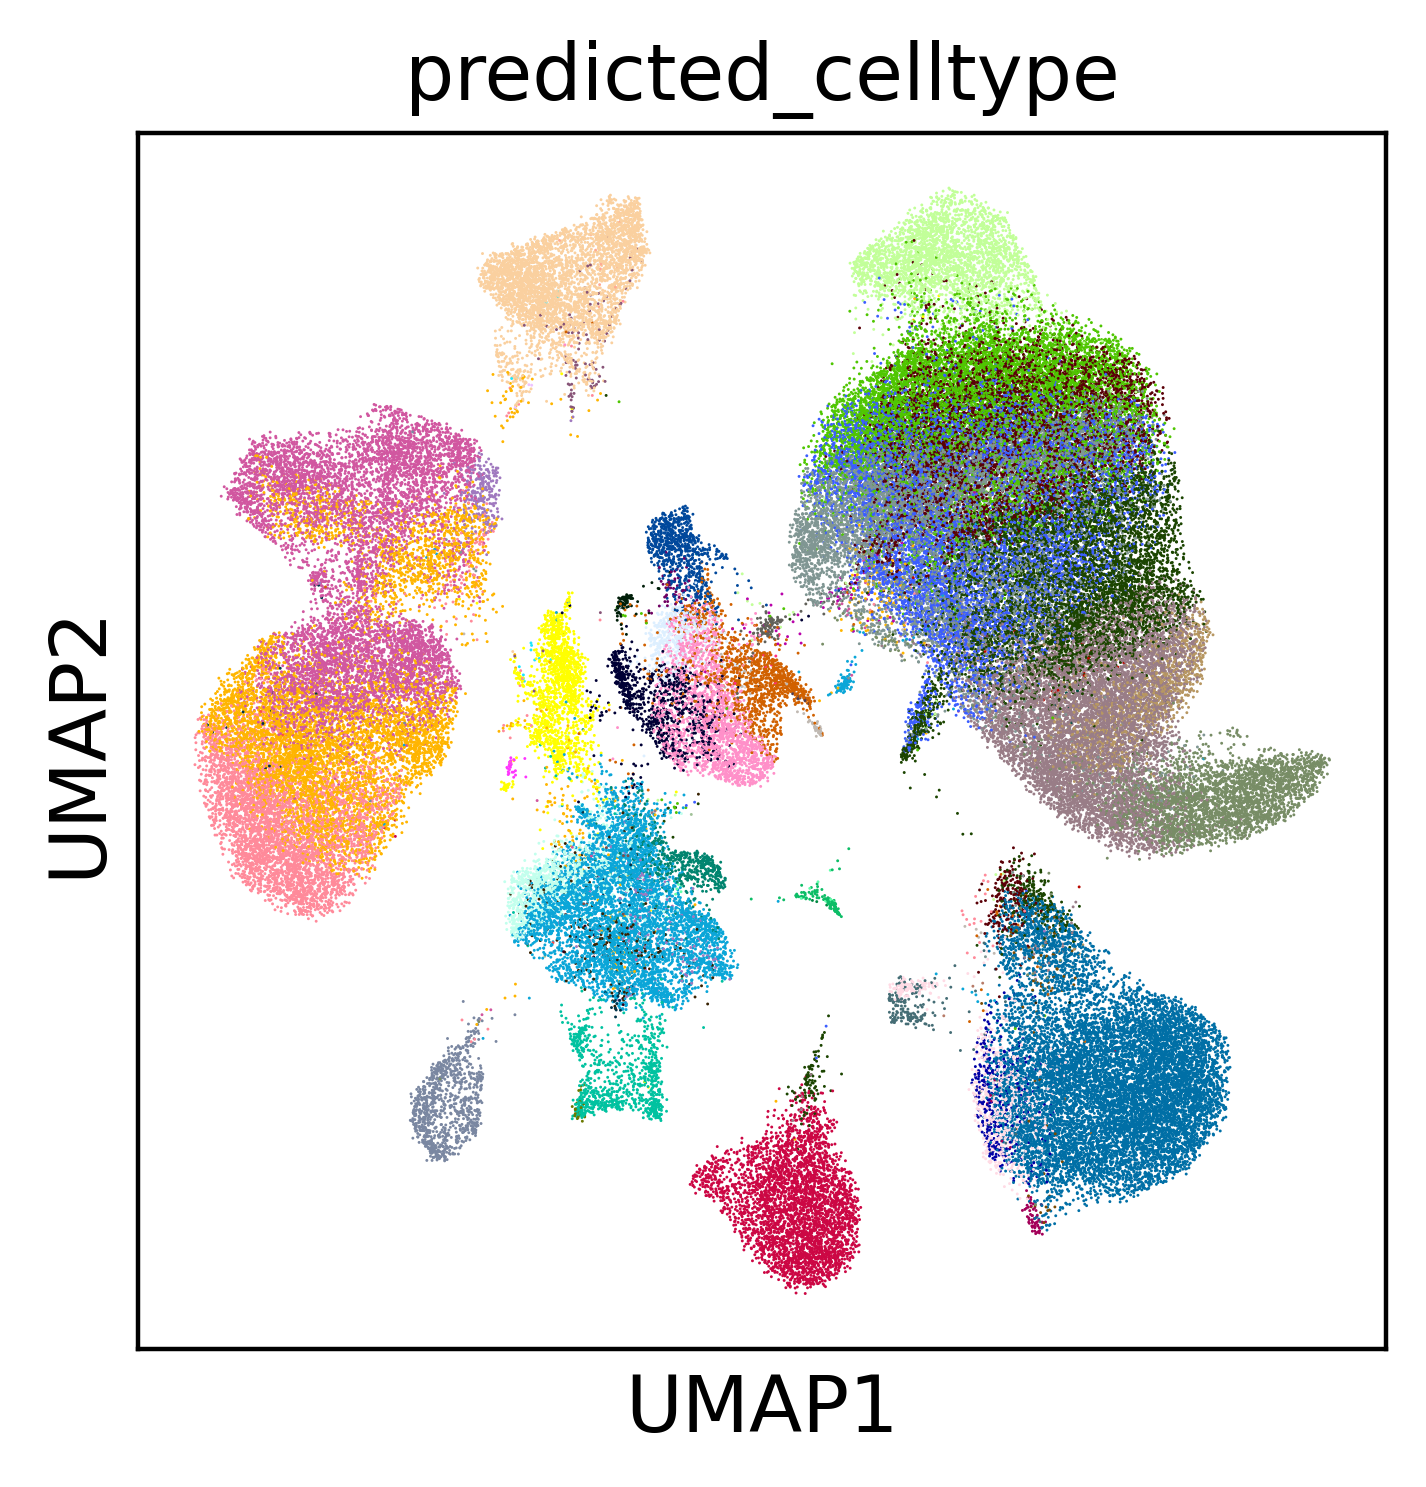

In [15]:
sc.pl.umap(
    expanded,
    color="predicted_celltype",
    legend_loc=None
)

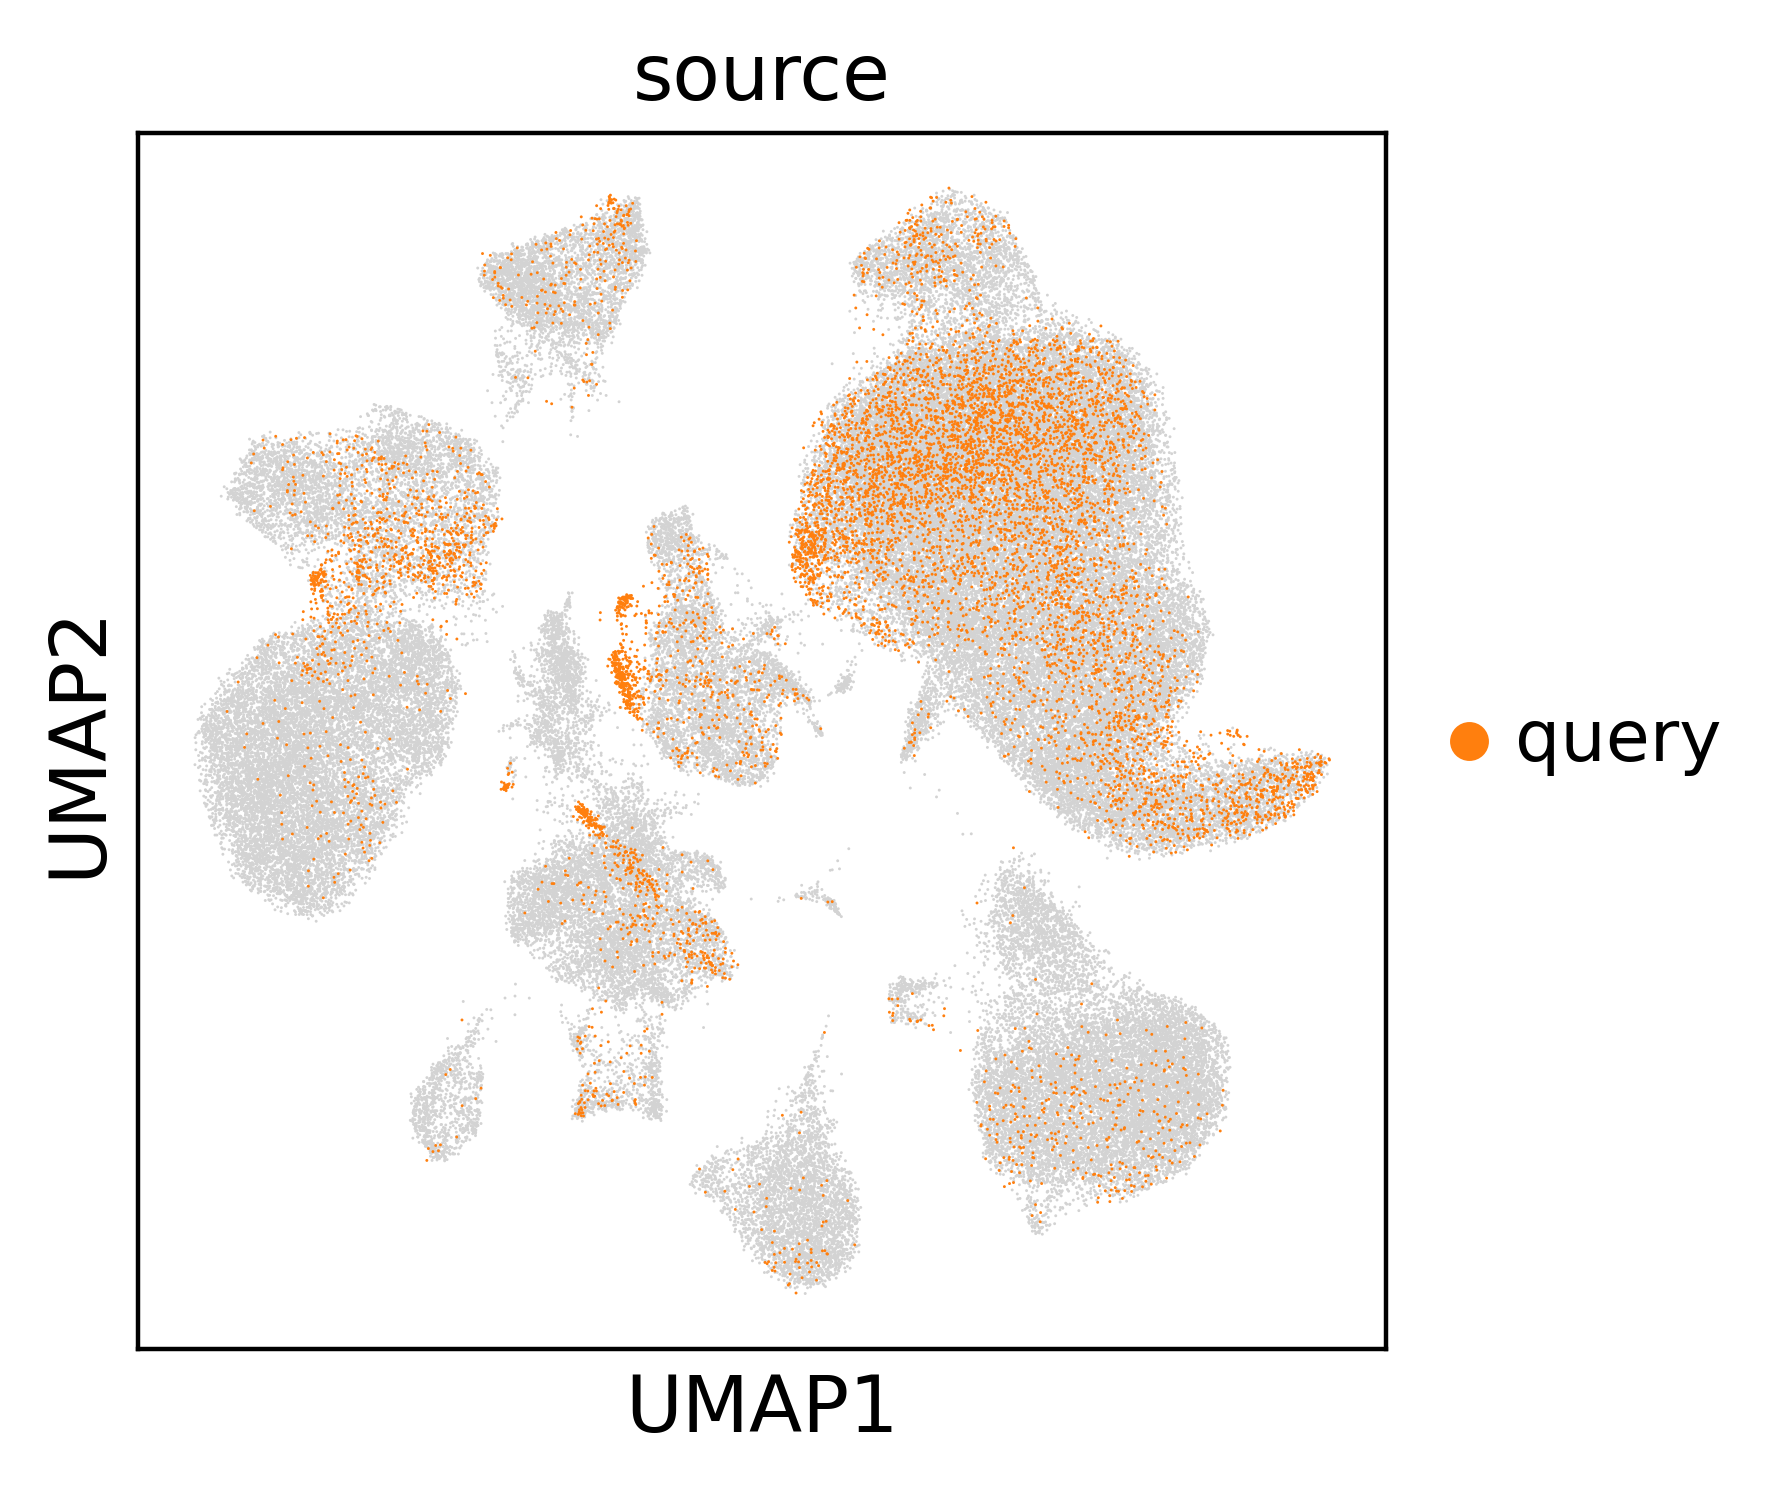

In [16]:
sc.pl.umap(expanded, color="source", groups="query", na_in_legend=False)

In [17]:
expanded

AnnData object with n_obs × n_vars = 109631 × 29305
    obs: 'Sample_ID', 'Condition', 'Treatment', 'TreatmentType', 'TreatmentStatus', 'Tissue', 'Sex', 'Dataset', 'Technology', 'Level_1', 'Level_2', 'Level_3', 'Level_4', 'Age', 'Diabetes', 'Is_Core', 'EMT category', 'Dataset_ID', 'Cluster_Names', 'source', 'predicted_celltype'
    var: 'n_cells', 'ensembl_id', 'start', 'end', 'chromosome', 'gene_name_adata_sc', 'highly_variable_adata_sc', 'means_adata_sc', 'dispersions_adata_sc', 'dispersions_norm_adata_sc', 'highly_variable_nbatches_adata_sc', 'highly_variable_intersection_adata_sc', 'n_cells_by_counts_adata_sc', 'mean_counts_adata_sc', 'log1p_mean_counts_adata_sc', 'pct_dropout_by_counts_adata_sc', 'total_counts_adata_sc', 'log1p_total_counts_adata_sc', 'mito_adata_sc', 'n_cells_by_counts_adata_sn', 'mean_counts_adata_sn', 'log1p_mean_counts_adata_sn', 'pct_dropout_by_counts_adata_sn', 'total_counts_adata_sn', 'log1p_total_counts_adata_sn', 'Manual_Genes', 'mt', 'ribo', 'hb', 'gene_

<Axes: title={'center': 'Distribution of predicted_celltype'}, xlabel='number of cells', ylabel='predicted_celltype'>

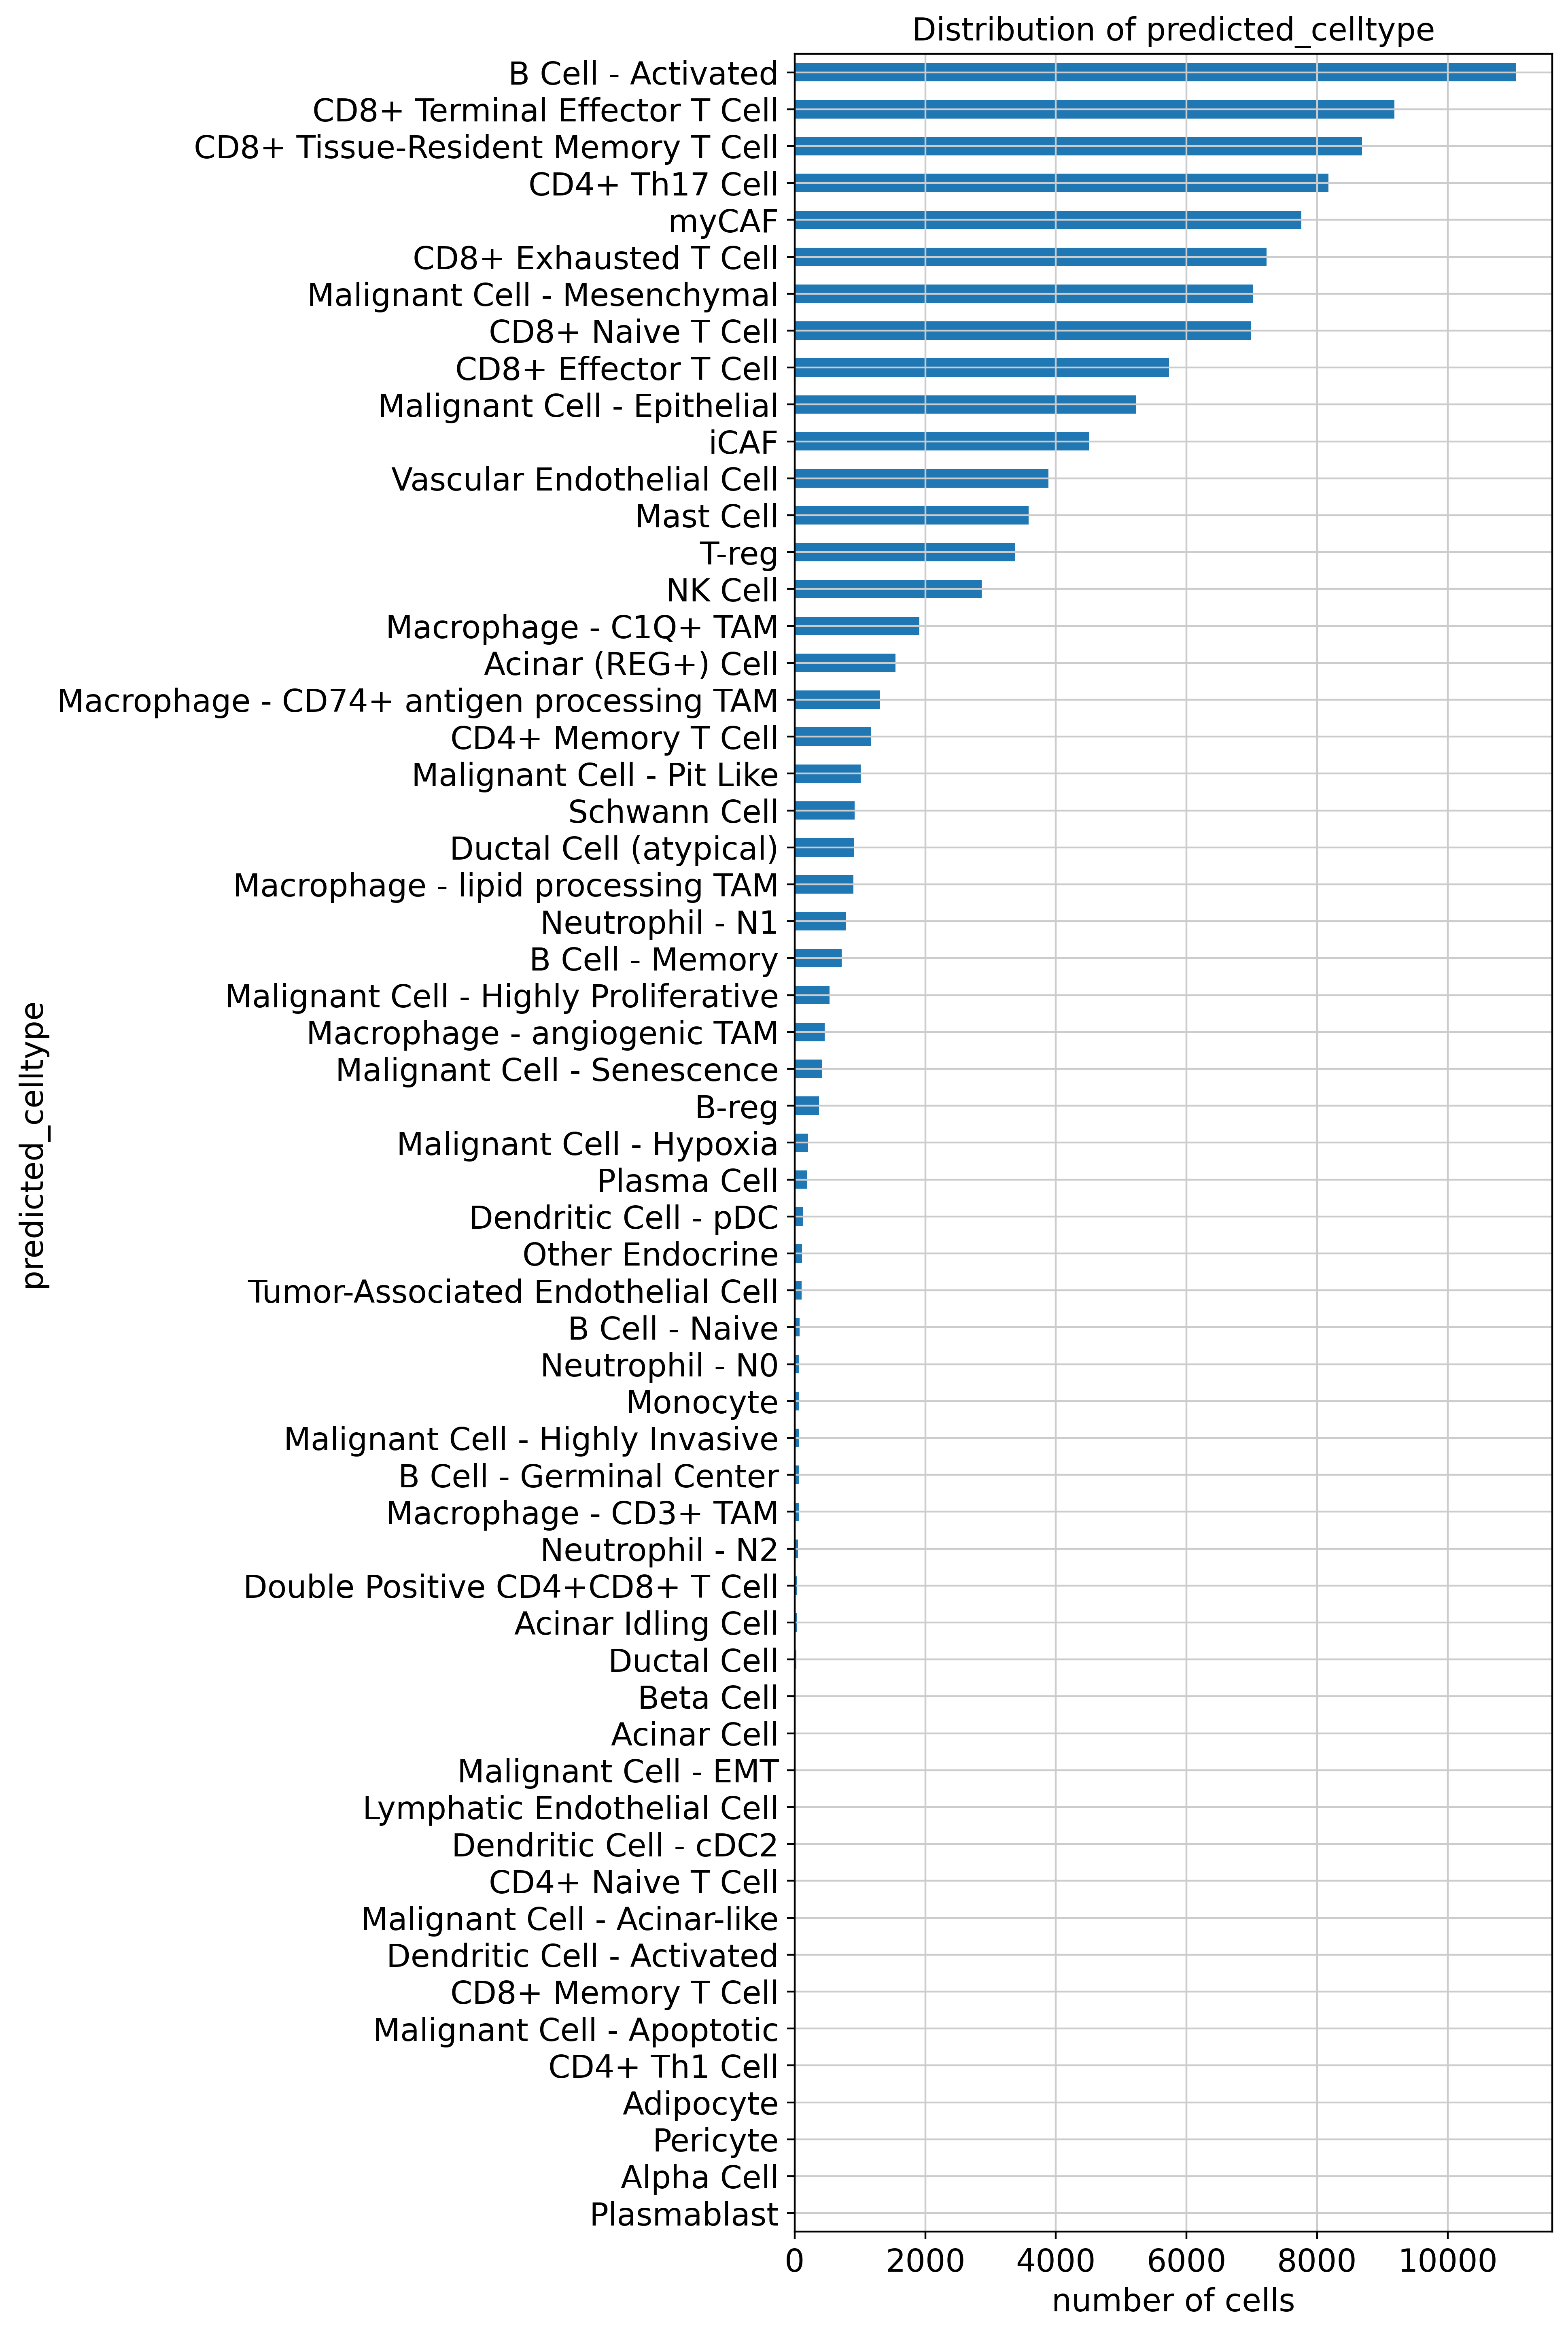

In [24]:
scpdac.pl.plot_label_distribution(expanded, key="predicted_celltype")

## 6. Embed-only: transfer labels without surgery

> ✅ **No atlas download needed.** This section only uses the query you loaded
> in Section 3 and the SCANVI model that ships with `scpdac`.

If you do not want to compare your data against the rest of the atlas, you can
simply use `scpdac.tl.embed_and_predict`, which embeds the query with the frozen
model and transfers labels in one step — faster, and it leaves the atlas
untouched. It writes the latent embedding to `obsm["X_scANVI_emb"]` and
predictions to `obs["predicted_celltype"]`.

In [18]:
query = scpdac.tl.embed_and_predict(query, SPECIES)

INFO     File .../scpdac/models/scanvi/human_scanvi/model.pt already       
         downloaded                                                                                                


Again we compute a UMAP from the embedding and colour by the predicted cell types
and by sample, to confirm the query integrates cleanly on its own.

In [19]:
sc.pp.neighbors(query, use_rep="X_scANVI_emb", transformer=AnnoyTransformer(15))

In [20]:
sc.tl.umap(
    query,
)

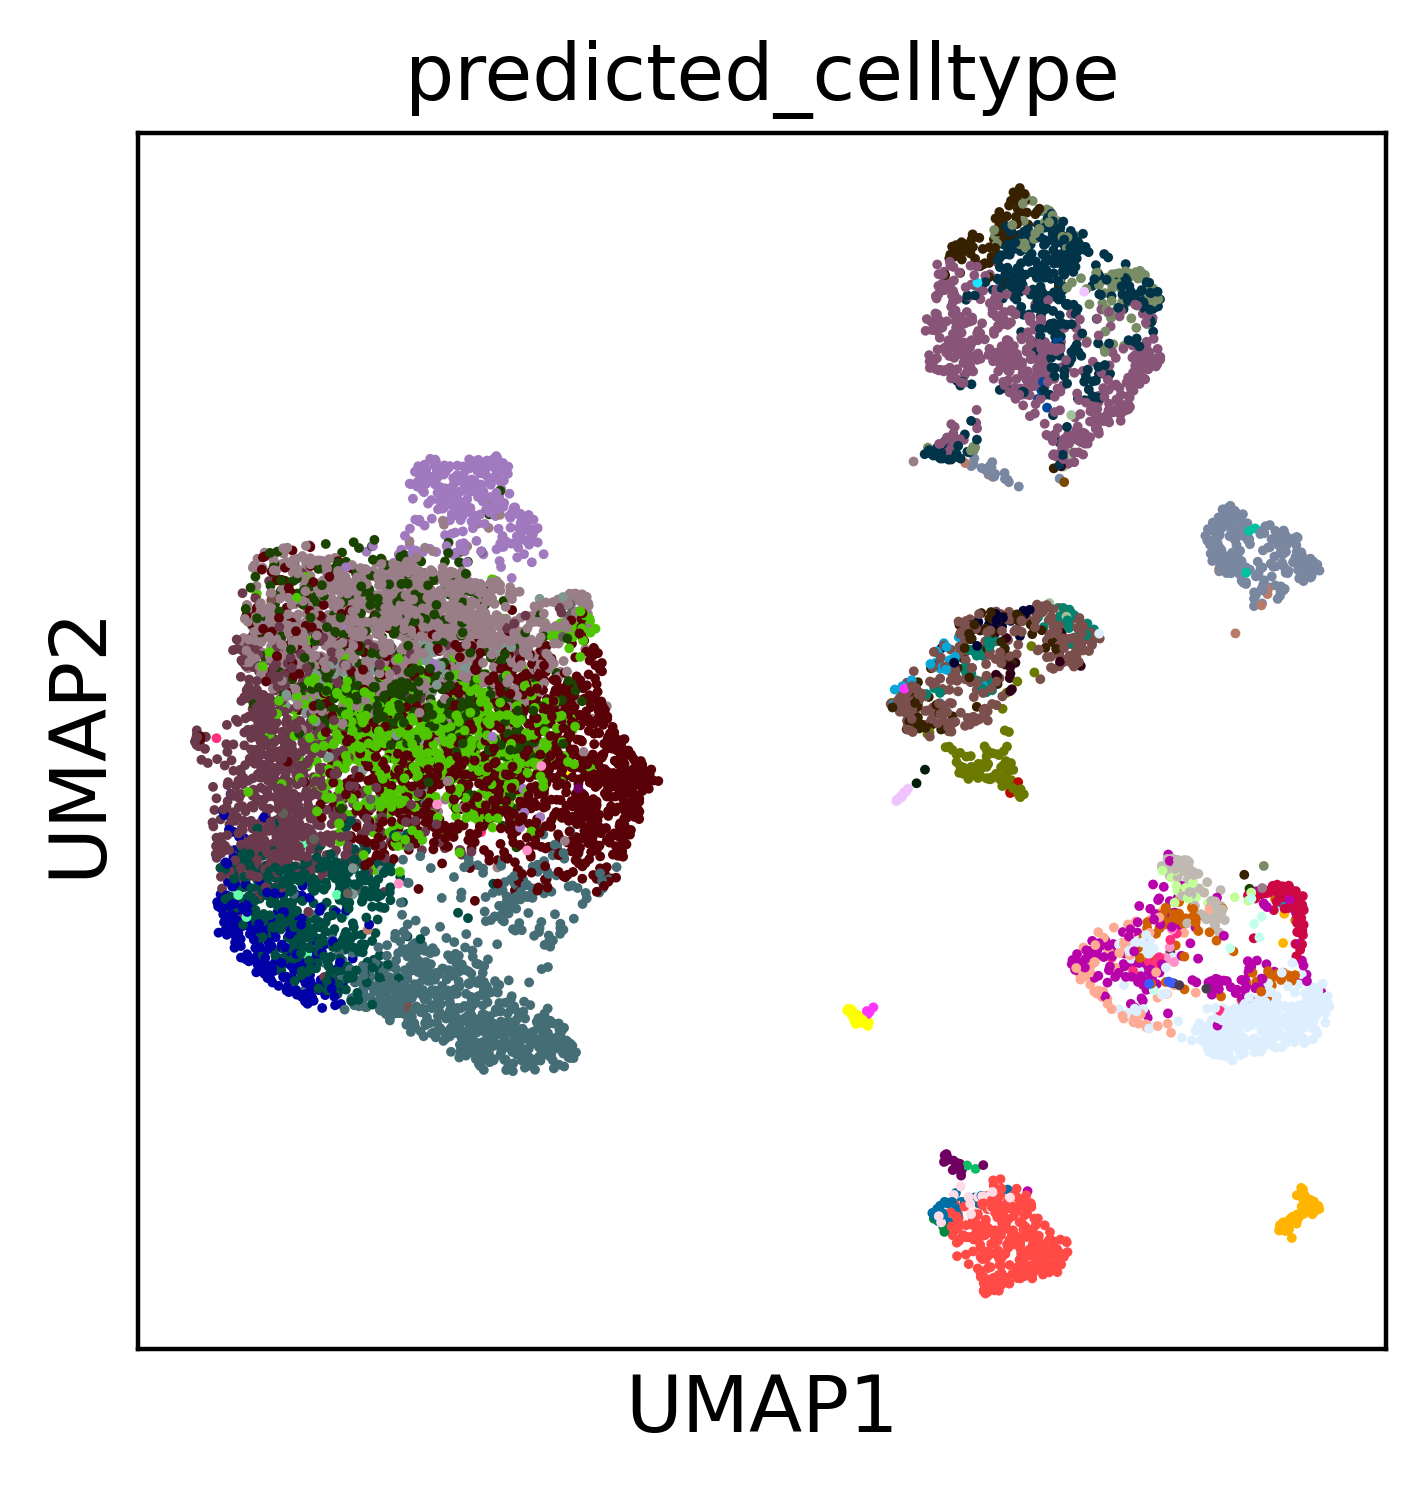

In [23]:
sc.pl.umap(
    query,
    color="predicted_celltype",
    legend_loc=None
)

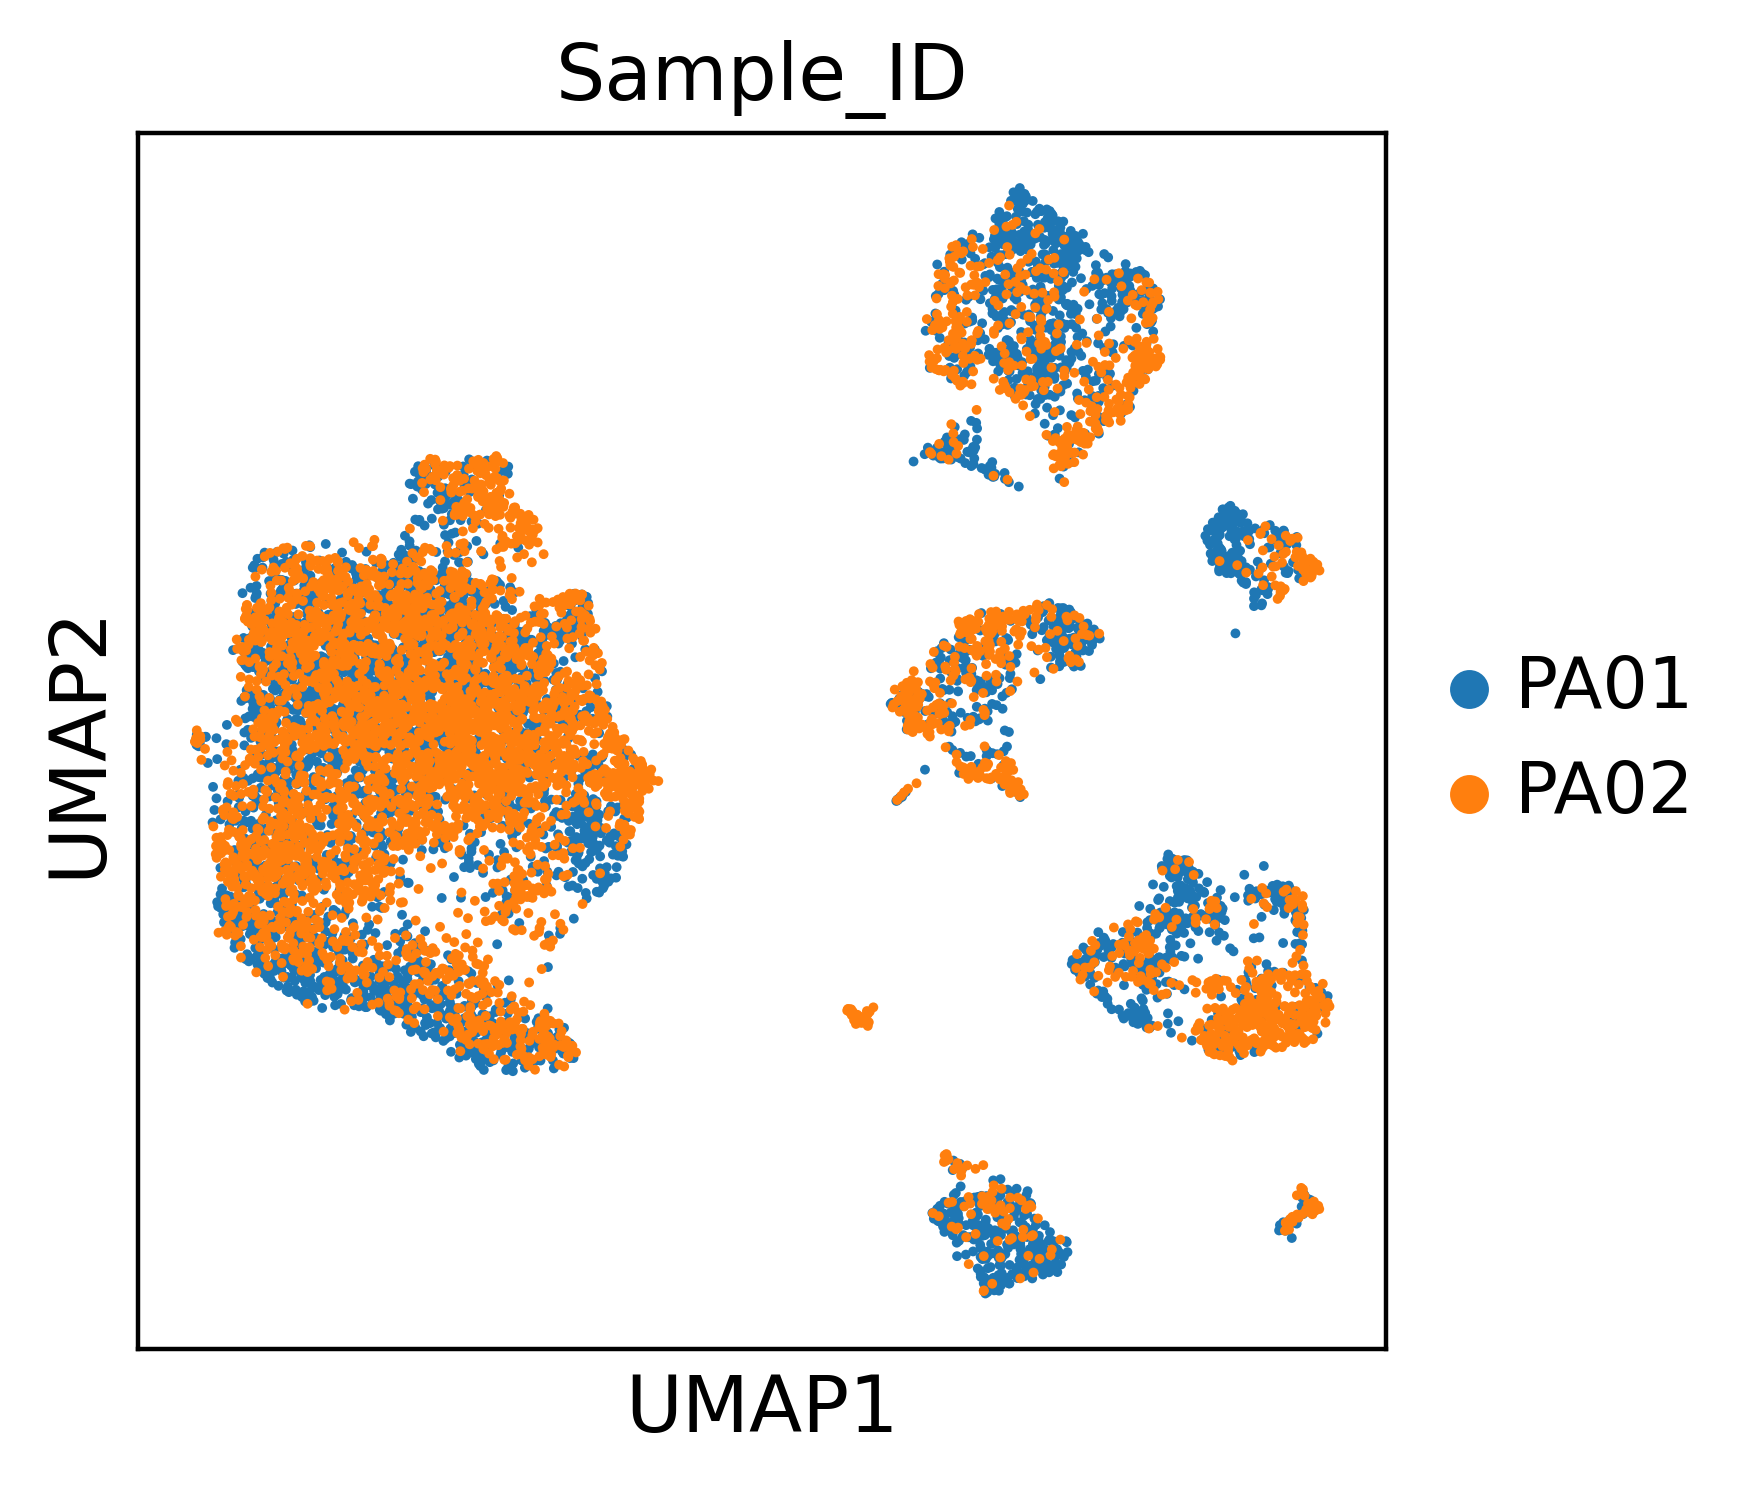

In [22]:
sc.pl.umap(
    query,
    color="Sample_ID",
)